<div style="background: linear-gradient(135deg, #0f172a, #020617); padding:40px; border-radius:20px; text-align:center; box-shadow:0 0 20px rgba(56,189,248,0.3);"><h1 style="color:#38bdf8; font-size:50px; font-weight:bold; letter-spacing:2px;">
📱 Smart Phone Addiction Classification
</h1><p style="color:#cbd5f5; font-size:20px; margin-top:10px;">
AI Model to Predict User Addiction Level Based on Usage Behavior
</p><hr style="border:1px solid #38bdf8; width:60%; margin:20px auto;"><p style="color:#94a3b8; font-size:18px;">
👨‍💻 Developed by <span style="color:#38bdf8; font-weight:bold;">Mohamed Walid</span> & 
<span style="color:#38bdf8; font-weight:bold;">Nahed</span> 🚀
</p></div>

## Data Overview

### About Dataset
This dataset focuses on understanding the patterns and effects of smartphone usage among teenagers, with a special focus on:
- Addiction levels
- Academic performance
- Time distribution (social media, gaming, education)
- Mental and physical health proxies

It enables researchers, educators, psychologists, and data scientists to explore and model behavioral trends, and build classification or regression models to predict addiction levels, performance, or placement outcomes.

### Column Description

| Column Name              | Description                                                   |
|--------------------------|---------------------------------------------------------------|
| Age                      | Age of the participant (in years)                             |
| Gender                   | Gender identity of the participant                             |
| Time_on_Social_Media     | Average daily time spent on social media (in hours)           |
| Time_on_Education        | Daily study/learning time (in hours)                          |
| Time_on_Gaming           | Daily gaming time (in hours)                                   |
| Phone_Checks_Per_Day     | How many times participant checks their phone per day         |
| Phone_Usage_Purpose      | Primary purpose of phone usage (social, gaming, education)   |
| Exercise_Hours           | Number of hours of physical activity per week                |
| Academic_Performance     | Academic score or GPA                                         |
| IQ                       | Self-reported or estimated intelligence score                |
| CG                       | Cumulative Grade (or general performance metric)             |
| Internship_Experience    | Binary or categorical indication of internship experience   |
| Projects_Completed       | Number of self-initiated or academic projects completed     |
| Placement                | Placement status (selected/not selected)                     |
| Addiction_Level          | Numeric measure of phone/screen addiction severity           |

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 26px;
">
    import library
</div>

In [127]:
# ================== Data & Math ==================
import pandas as pd
import numpy as np
import math

# ================== Visualization ==================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ================== Data Preprocessing ==================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler

# ================== Encoding ==================
from category_encoders import OneHotEncoder, BinaryEncoder, OrdinalEncoder

# ================== Imbalanced Data ==================
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import resample

# ================== Feature Selection & Statistics ==================
from sklearn.feature_selection import f_classif, chi2
from scipy.stats import spearmanr, chi2_contingency

# ================== Models ==================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# ================== Model Evaluation ==================
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# ================== General Settings ==================
import warnings
warnings.filterwarnings('ignore')

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 26px;
">
    OverView
</div>

In [128]:
df= pd.read_csv( "teen_phone_addiction_dataset.csv")

df

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Jesus Yates,16,Female,New Jennifer,12th,3.9,6.4,53,4,...,0.3,80,15,2.7,1.8,1.0,Other,8,9.4,9.8
2996,2997,Bethany Murray,13,Female,Richardport,8th,3.6,7.3,93,5,...,0.9,45,8,3.1,0.0,0.3,Gaming,9,5.2,5.5
2997,2998,Norman Hughes,14,Other,Rebeccaton,7th,3.2,6.5,98,1,...,0.2,51,13,2.4,0.2,2.4,Social Media,9,5.9,6.2
2998,2999,Barbara Hinton,17,Female,Ramirezmouth,9th,6.7,7.5,67,3,...,1.6,125,17,1.7,2.6,1.5,Browsing,4,6.1,10.0


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental_Control        3000 non-null   

In [130]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df

In [131]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,ID,int64,"[3000, 1, 2, 3, 4, 5, 6, 7, 2984, 2983]",3000,0,0.0,0
1,Name,object,"[Gregory Johnson, Richard Smith, David William...",2933,0,0.0,0
2,Age,int64,"[16, 13, 15, 14, 19, 17, 18]",7,0,0.0,0
3,Gender,object,"[Male, Female, Other]",3,0,0.0,0
4,Location,object,"[North Michael, Lake Michael, Lake James, Nort...",2726,0,0.0,0
5,School_Grade,object,"[12th, 9th, 7th, 10th, 8th, 11th]",6,0,0.0,0
6,Daily_Usage_Hours,float64,"[4.4, 4.9, 4.3, 5.3, 5.0, 5.4, 4.7, 6.2, 4.1, ...",107,0,0.0,0
7,Sleep_Hours,float64,"[6.1, 7.1, 6.5, 6.8, 6.9, 5.8, 6.6, 6.3, 6.2, ...",71,0,0.0,0
8,Academic_Performance,int64,"[93, 98, 59, 62, 82, 57, 84, 77, 75, 85]",51,0,0.0,0
9,Social_Interactions,int64,"[8, 5, 9, 6, 4, 3, 1, 10, 7, 0]",11,0,0.0,0


In [132]:
df.describe().T.style.bar(subset=['mean'], color='#FFA07A').background_gradient(
    subset=['std', '50%', 'max'], cmap='Blues').set_properties(
        **{'font-size': '12pt', 'border': '1.5px solid black'}).set_caption("🔍 Summary Statistics of the Dataset")

,count,mean,std,min,25%,50%,75%,max
ID,3000.000000,1500.500000,866.169729,1.000000,750.750000,1500.500000,2250.250000,3000.000000
Age,3000.000000,15.969667,1.989489,13.000000,14.000000,16.000000,18.000000,19.000000
Daily_Usage_Hours,3000.000000,5.020667,1.956501,0.000000,3.700000,5.000000,6.400000,11.500000
Sleep_Hours,3000.000000,6.489767,1.490713,3.000000,5.500000,6.500000,7.500000,10.000000
Academic_Performance,3000.000000,74.947333,14.684156,50.000000,62.000000,75.000000,88.000000,100.000000
Social_Interactions,3000.000000,5.097667,3.139333,0.000000,2.000000,5.000000,8.000000,10.000000
Exercise_Hours,3000.000000,1.040667,0.734620,0.000000,0.500000,1.000000,1.500000,4.000000
Anxiety_Level,3000.000000,5.590000,2.890678,1.000000,3.000000,6.000000,8.000000,10.000000
Depression_Level,3000.000000,5.460333,2.871557,1.000000,3.000000,5.000000,8.000000,10.000000
Self_Esteem,3000.000000,5.546333,2.860754,1.000000,3.000000,6.000000,8.000000,10.000000


In [133]:
df.drop(columns=['ID','Name','Location'], inplace=True)

In [134]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,Age,int64,"[16, 13, 15, 14, 19, 17, 18]",7,0,0.0,0
1,Gender,object,"[Male, Female, Other]",3,0,0.0,0
2,School_Grade,object,"[12th, 9th, 7th, 10th, 8th, 11th]",6,0,0.0,0
3,Daily_Usage_Hours,float64,"[4.4, 4.9, 4.3, 5.3, 5.0, 5.4, 4.7, 6.2, 4.1, ...",107,0,0.0,0
4,Sleep_Hours,float64,"[6.1, 7.1, 6.5, 6.8, 6.9, 5.8, 6.6, 6.3, 6.2, ...",71,0,0.0,0
5,Academic_Performance,int64,"[93, 98, 59, 62, 82, 57, 84, 77, 75, 85]",51,0,0.0,0
6,Social_Interactions,int64,"[8, 5, 9, 6, 4, 3, 1, 10, 7, 0]",11,0,0.0,0
7,Exercise_Hours,float64,"[0.0, 0.9, 1.1, 1.0, 0.8, 1.3, 1.4, 1.2, 1.5, ...",39,0,0.0,0
8,Anxiety_Level,int64,"[10, 9, 6, 5, 4, 2, 7, 1, 8, 3]",10,0,0.0,0
9,Depression_Level,int64,"[1, 6, 4, 5, 9, 7, 3, 10, 8, 2]",10,0,0.0,0


In [135]:
Numerical_Cols=df.select_dtypes(include=['int64','float64']).columns.to_list()
Categorical_Cols=df.select_dtypes(include=['object']).columns.to_list()

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 26px;
">
   Data Analysis
</div>

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 18px;
">
    Nomircal col
</div>

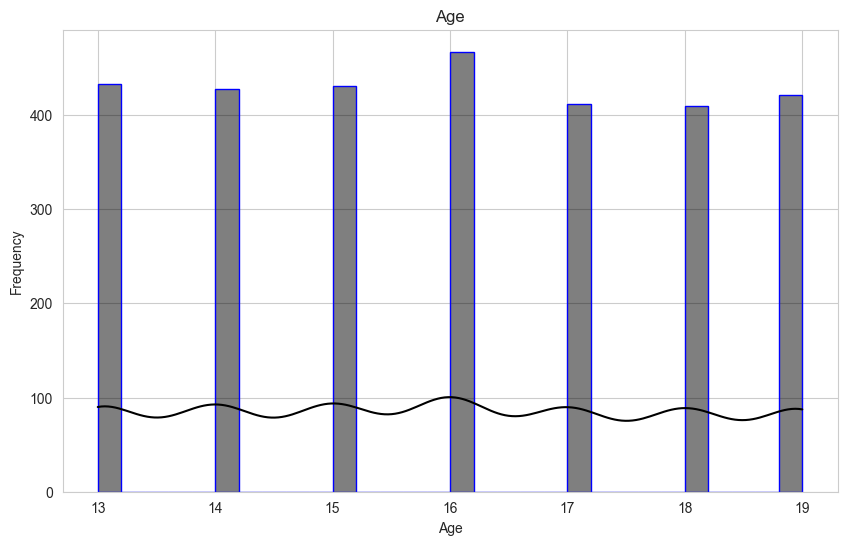

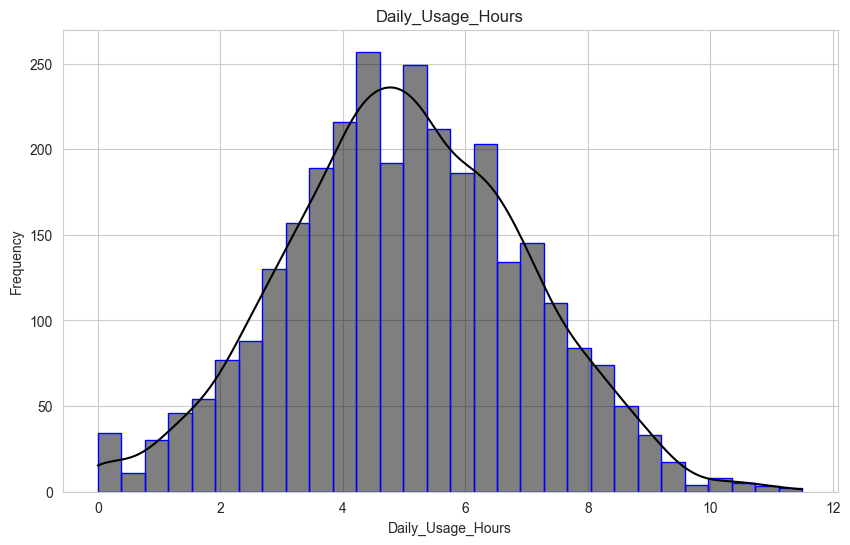

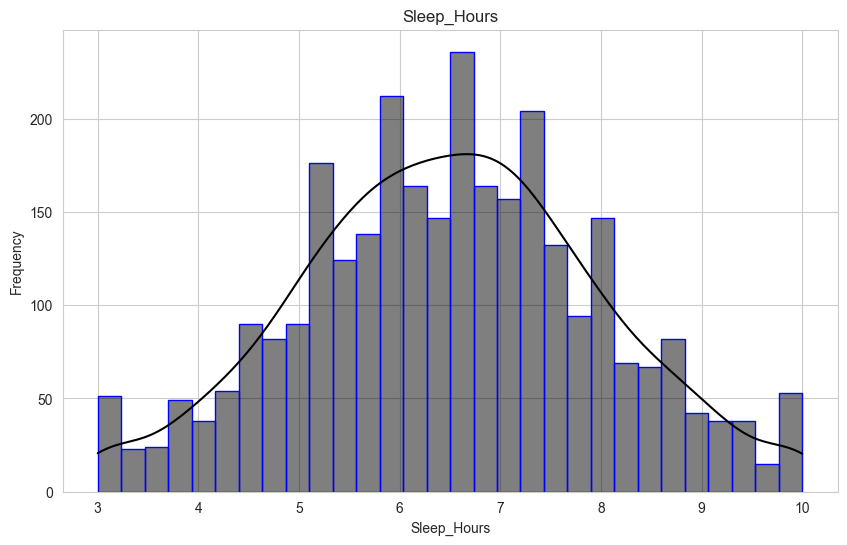

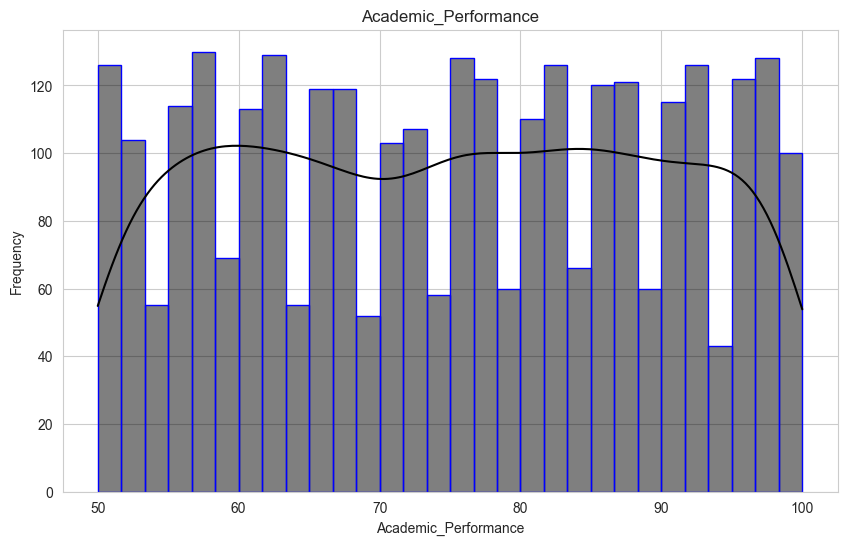

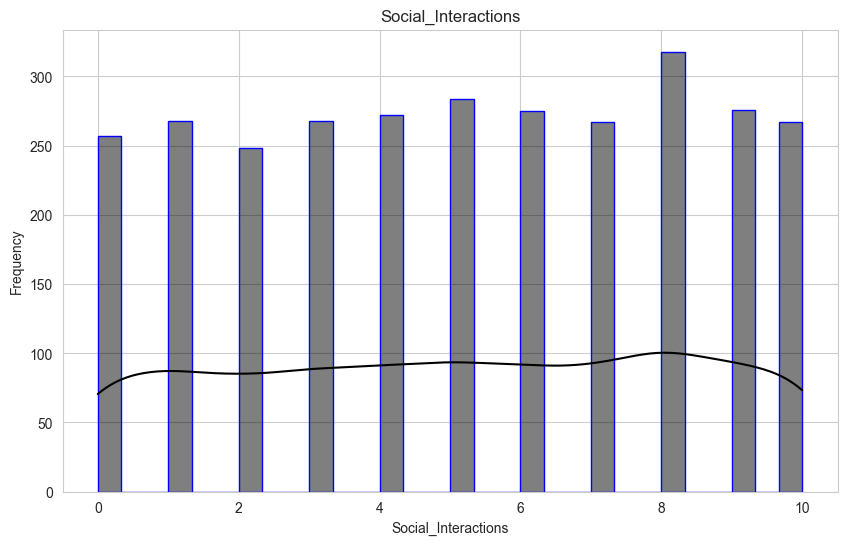

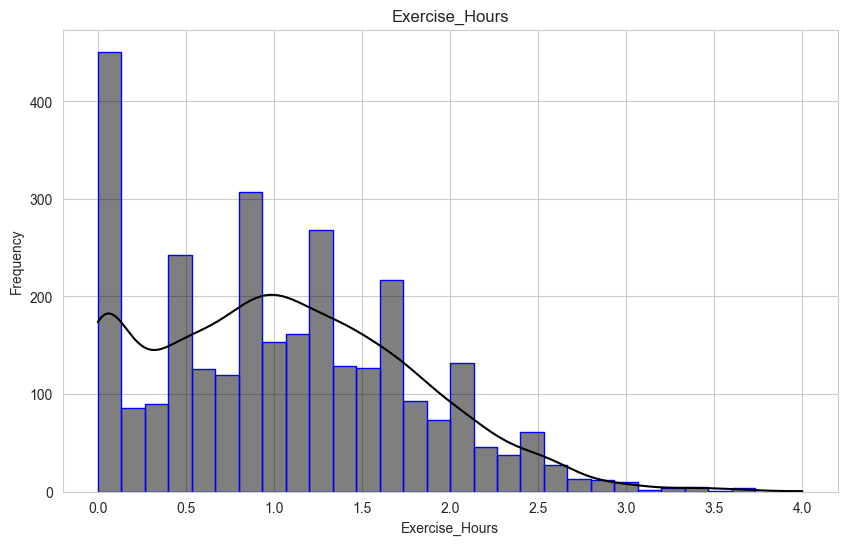

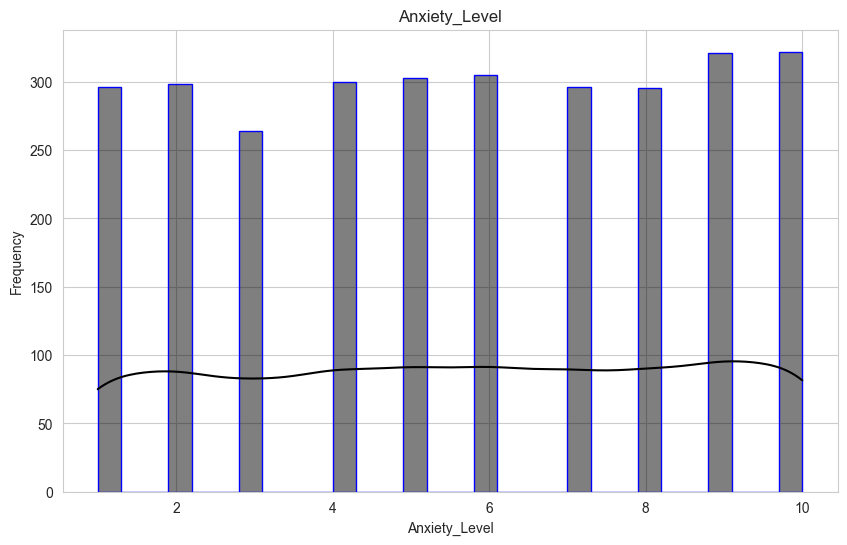

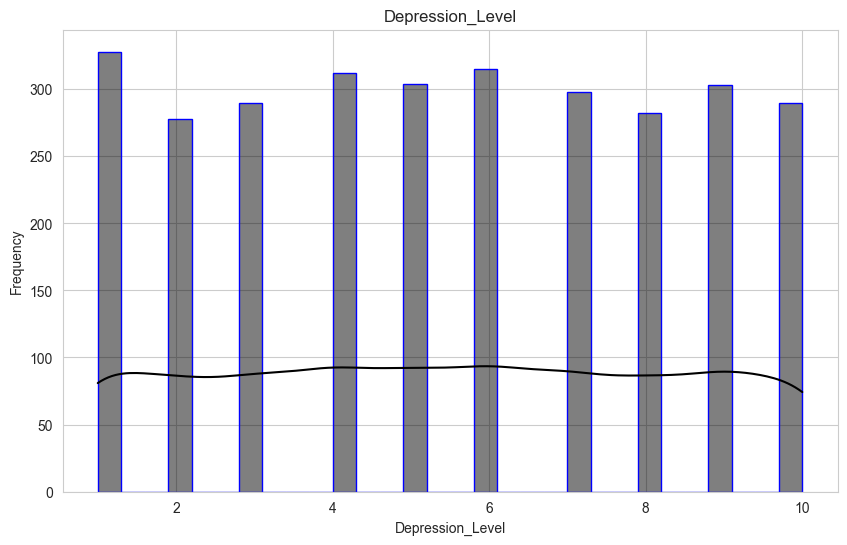

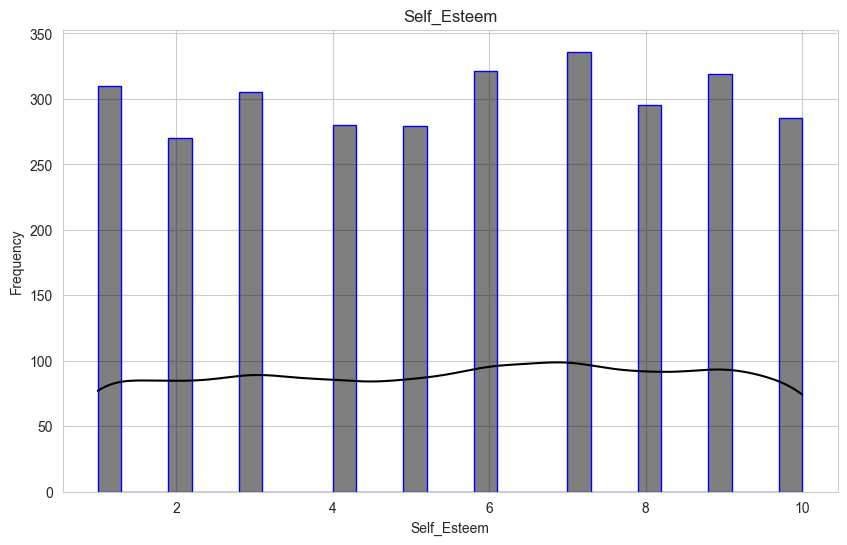

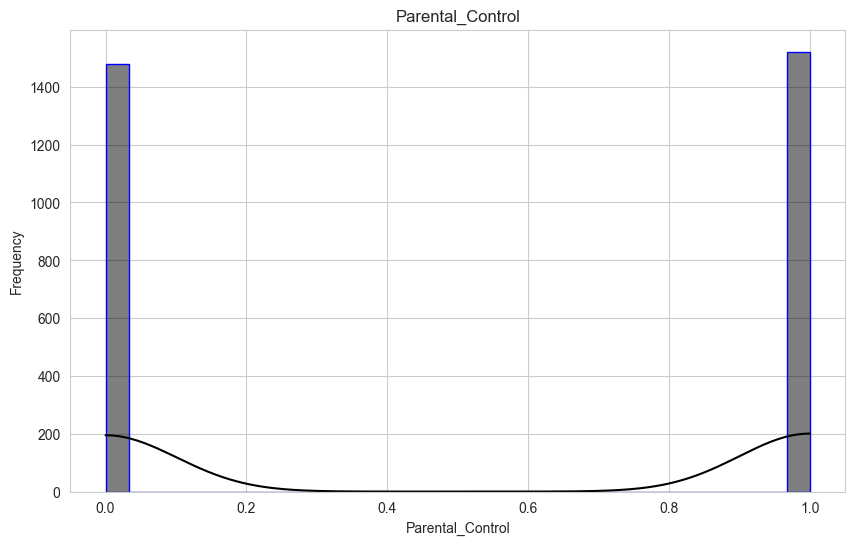

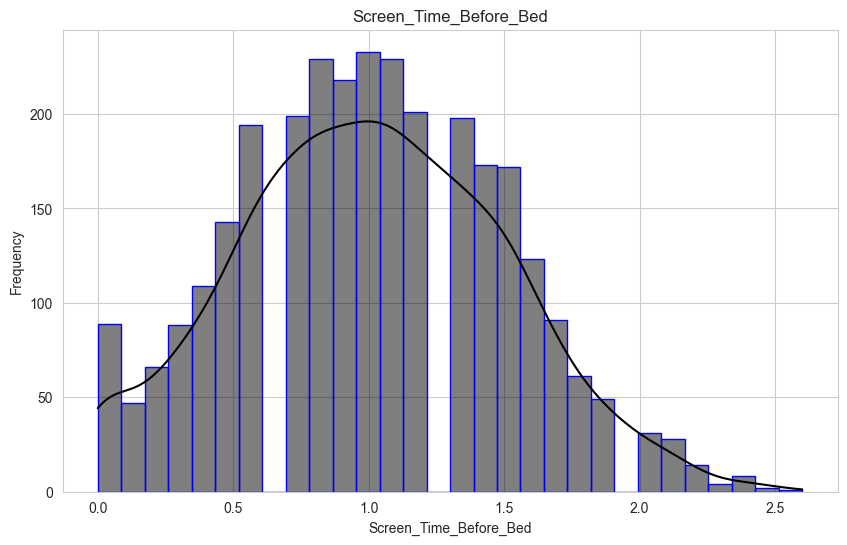

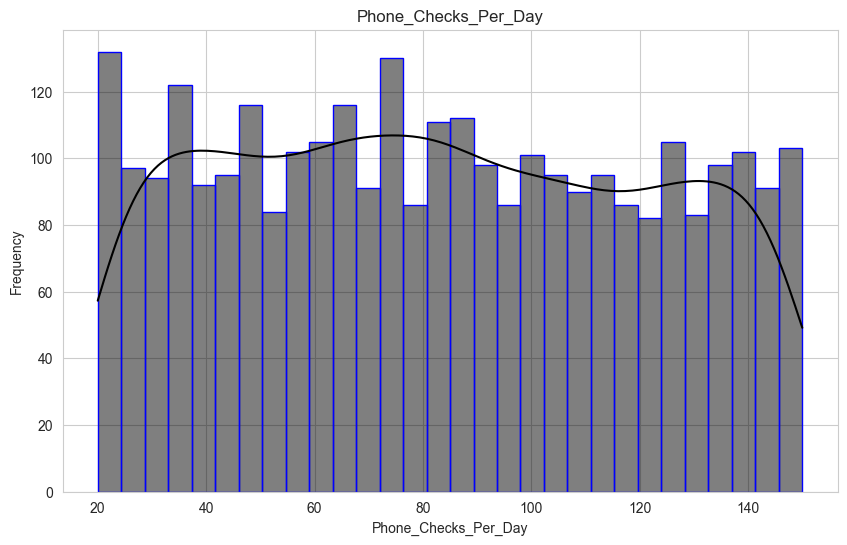

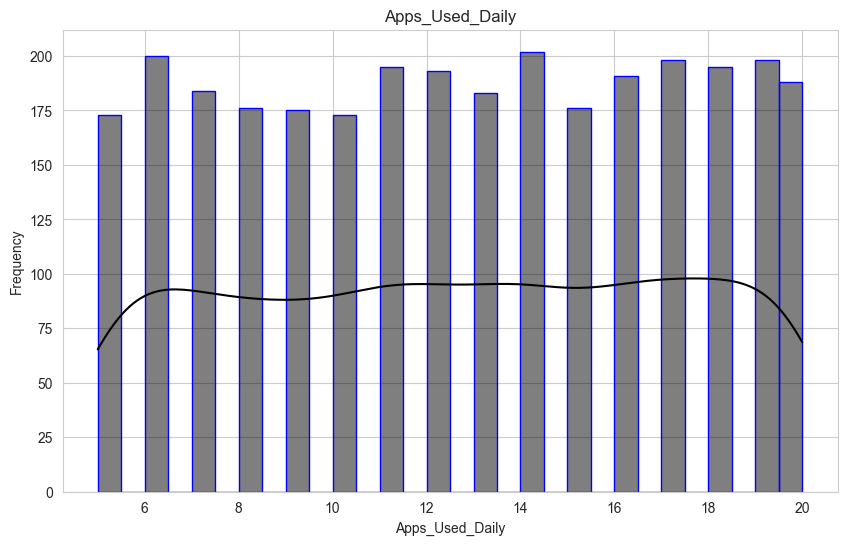

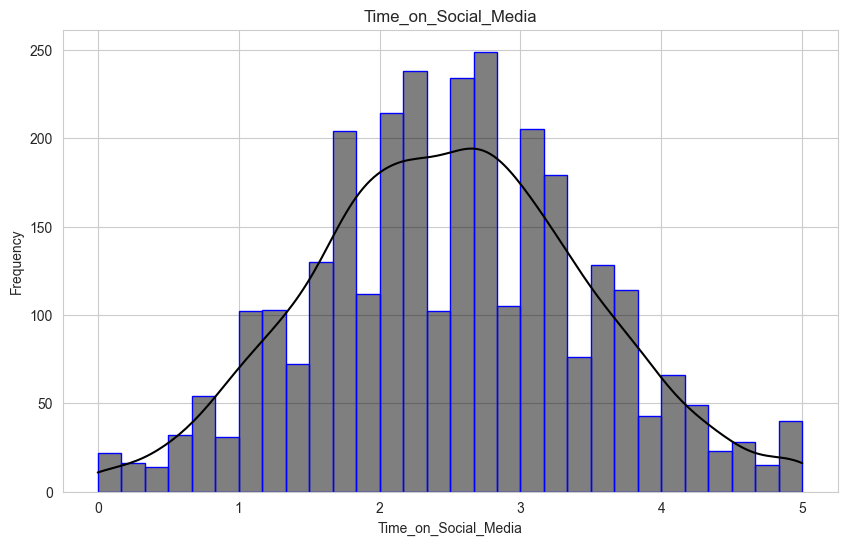

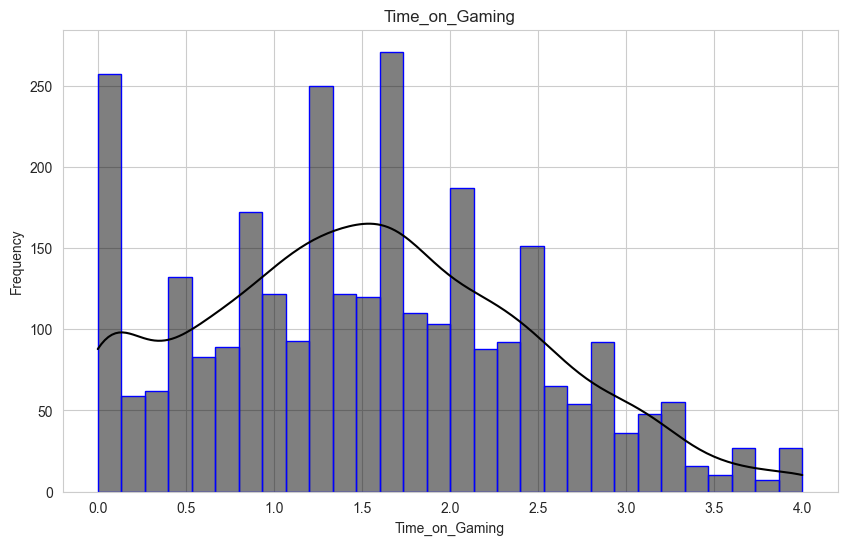

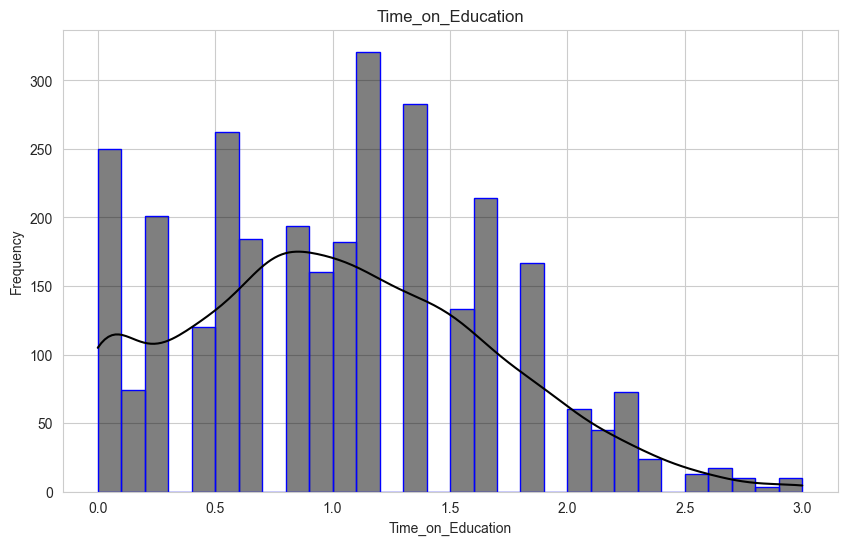

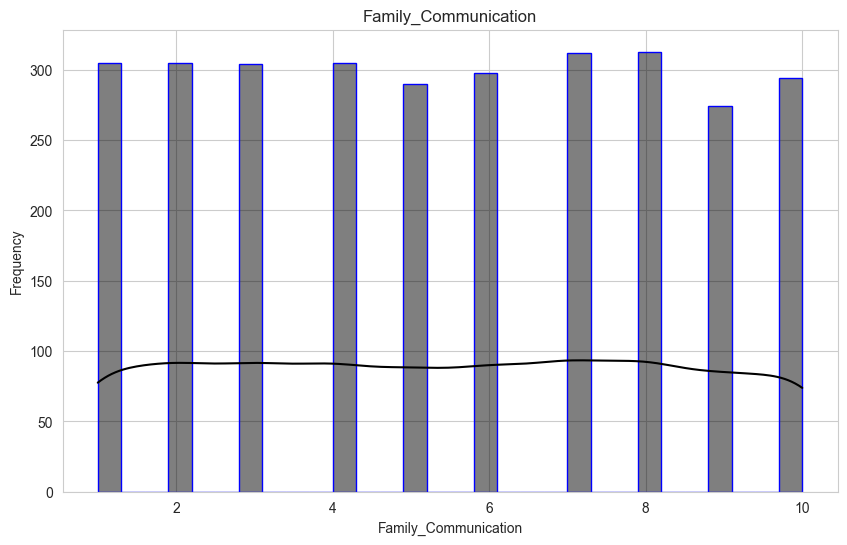

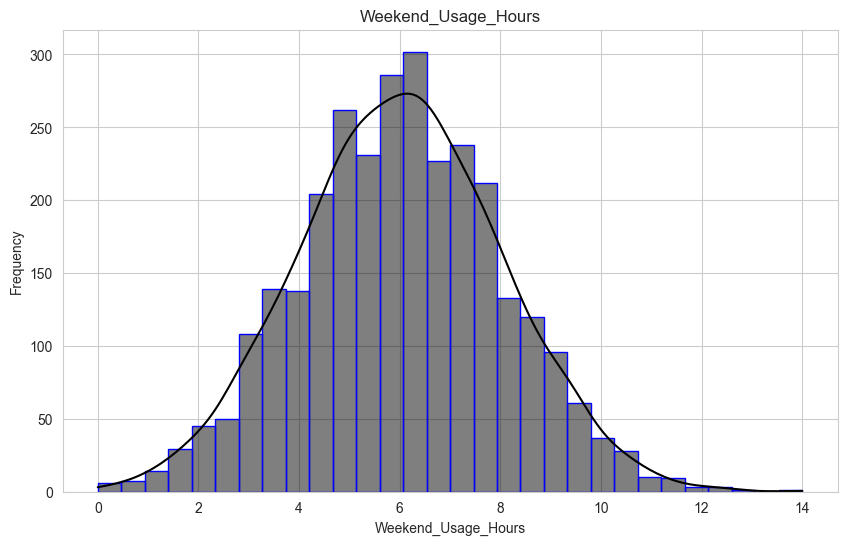

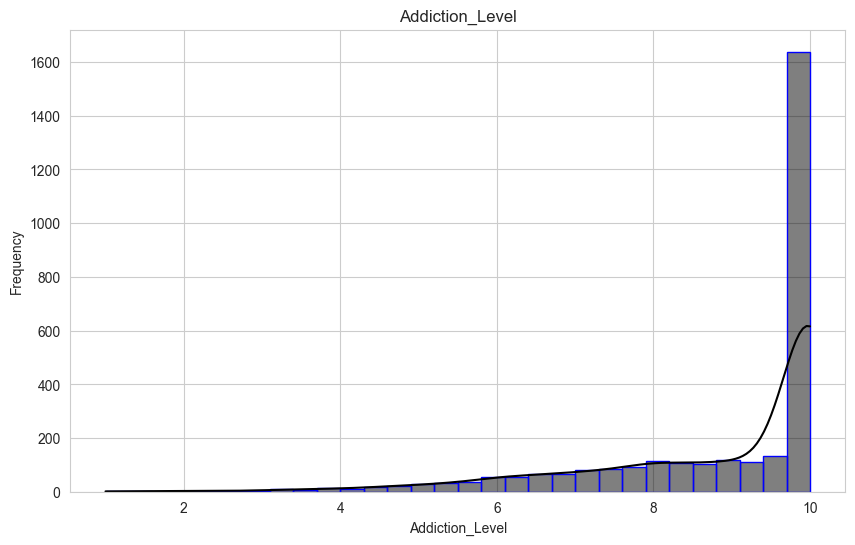

In [136]:
for col in Numerical_Cols:
  if col != 'TotalCharges':
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True, color='black', edgecolor='blue', bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

<h1 style="color:#1E90FF; text-align:center;">📊 Teen Phone Addiction – Numerical Columns Insights</h1>

<h2 style="color:#FF4500;">1️⃣ Distribution of Numerical Columns</h2>
<ul>
  <li><b>Age:</b> <span style="color:#2E8B57;">Most teens are between 15–17 years, distribution is roughly normal.</span></li>
  <li><b>Time_on_Social_Media:</b> <span style="color:#DAA520;">Right-skewed, a few teens use more than 8 hours/day.</span></li>
  <li><b>Time_on_Games:</b> <span style="color:#FF6347;">Most values are under 4 hours/day, few play more than 6 hours.</span></li>
  <li><b>Time_on_Education:</b> <span style="color:#4682B4;">Most teens study 2–4 hours/day.</span></li>
  <li><b>Phone_Checks_Per_Day:</b> <span style="color:#B22222;">Right-skewed, some teens check >100 times/day.</span></li>
  <li><b>Academic_Performance:</b> <span style="color:#6A5ACD;">Average around 78, most scores between 70–90.</span></li>
  <li><b>Addiction_Level:</b> <span style="color:#FF1493;">Mostly 2–4, a few extreme cases at 5.</span></li>
</ul>

<h2 style="color:#FF4500;">2️⃣ Outliers & Observations</h2>
<ul>
  <li><b>Phone_Checks_Per_Day:</b> <span style="color:#B22222;">Extreme values exist (>100), consider these for analysis.</span></li>
  <li><b>Time_on_Social_Media:</b> <span style="color:#DAA520;">Some teens overuse the phone significantly.</span></li>
  <li><b>Academic_Performance:</b> <span style="color:#6A5ACD;">A few low scores (<60) despite most being average/good.</span></li>
</ul>

<h2 style="color:#FF4500;">3️⃣ Summary Insights</h2>
<ul>
  <li><span style="color:#2E8B57;">Excessive phone/social media use is common among some teens.</span></li>
  <li><span style="color:#4682B4;">Educational hours are generally lower than social/media time.</span></li>
  <li><span style="color:#FF1493;">Some teens show extreme behaviors (high addiction/overuse), worth noting for modeling.</span></li>
</ul>

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 18px;
">
    Catogiral col
</div>

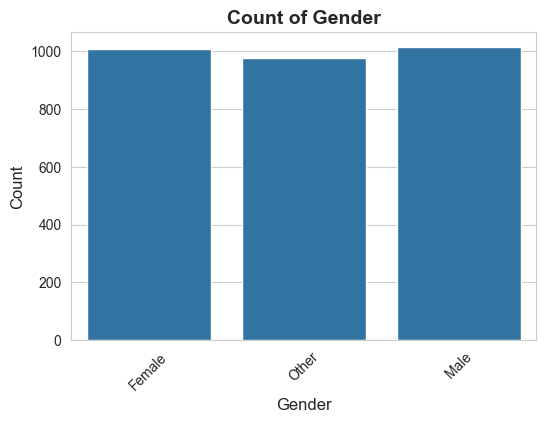

In [137]:
plt.figure(figsize=(6, 4))           
sns.countplot(data=df, x='Gender')    
plt.title('Count of Gender', fontsize=14, weight='bold')  
plt.xlabel('Gender', fontsize=12)      
plt.ylabel('Count', fontsize=12) 
plt.xticks(rotation=45)           
plt.show()


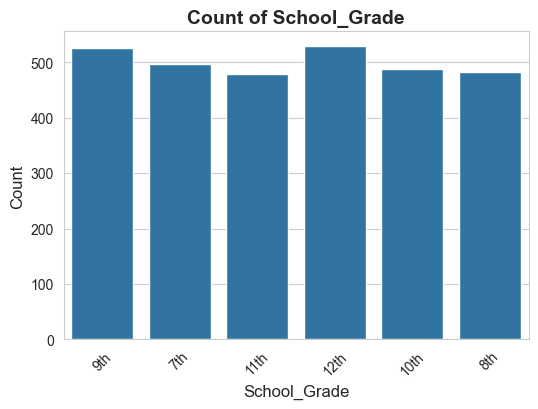

In [138]:
plt.figure(figsize=(6, 4))           
sns.countplot(data=df, x='School_Grade')    
plt.title('Count of School_Grade', fontsize=14, weight='bold')  
plt.xlabel('School_Grade', fontsize=12)      
plt.ylabel('Count', fontsize=12) 
plt.xticks(rotation=45)           
plt.show()


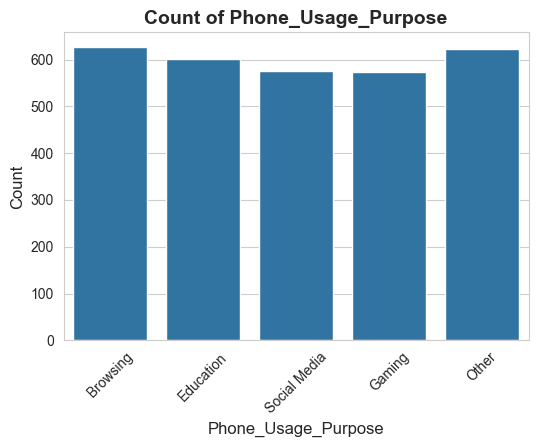

In [139]:
plt.figure(figsize=(6, 4))           
sns.countplot(data=df, x='Phone_Usage_Purpose')    
plt.title('Count of Phone_Usage_Purpose', fontsize=14, weight='bold')  
plt.xlabel('Phone_Usage_Purpose', fontsize=12)      
plt.ylabel('Count', fontsize=12) 
plt.xticks(rotation=45)           
plt.show()


<h1 style="color:#1E90FF; text-align:center;">📊 Teen Phone Addiction – Categorical Columns Insights</h1>

<h2 style="color:#FF4500;">1️⃣ Gender Distribution</h2>
<ul>
  <li><b>Gender:</b> <span style="color:#2E8B57;">Balanced distribution between Male and Female teens, with slight variation in some samples.</span></li>
</ul>

<h2 style="color:#FF4500;">2️⃣ Addiction Levels (Categorical)</h2>
<ul>
  <li><b>Addiction_Level (Low/Medium/High):</b> <span style="color:#DAA520;">Most teens are in Medium category, a few in High, and fewer in Low.</span></li>
</ul>

<h2 style="color:#FF4500;">3️⃣ Academic Performance Categories</h2>
<ul>
  <li><b>Academic_Category (e.g., Poor/Average/Good/Excellent):</b> <span style="color:#4682B4;">Majority of students fall into Average or Good category, very few are Poor or Excellent.</span></li>
</ul>

<h2 style="color:#FF4500;">4️⃣ Observations & Insights</h2>
<ul>
  <li><span style="color:#B22222;">High addiction teens are slightly more common among males than females.</span></li>
  <li><span style="color:#FF1493;">Students with Low academic performance tend to have higher addiction levels.</span></li>
  <li><span style="color:#2E8B57;">Medium addiction level is the most frequent category across the dataset.</span></li>
</ul>

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 18px;
">
    Target col
</div>

In [140]:
#   group for Addicition_level
df['Group_Addiction_Level'] = df['Addiction_Level'].apply(lambda x: 'Low' if x <= 4.0 else ('Moderate' if x < 8.0 else 'Strong'))

In [141]:
df.drop(columns=['Addiction_Level','School_Grade'], inplace=True)

In [142]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,Age,int64,"[16, 13, 15, 14, 19, 17, 18]",7,0,0.0,0
1,Gender,object,"[Male, Female, Other]",3,0,0.0,0
2,Daily_Usage_Hours,float64,"[4.4, 4.9, 4.3, 5.3, 5.0, 5.4, 4.7, 6.2, 4.1, ...",107,0,0.0,0
3,Sleep_Hours,float64,"[6.1, 7.1, 6.5, 6.8, 6.9, 5.8, 6.6, 6.3, 6.2, ...",71,0,0.0,0
4,Academic_Performance,int64,"[93, 98, 59, 62, 82, 57, 84, 77, 75, 85]",51,0,0.0,0
5,Social_Interactions,int64,"[8, 5, 9, 6, 4, 3, 1, 10, 7, 0]",11,0,0.0,0
6,Exercise_Hours,float64,"[0.0, 0.9, 1.1, 1.0, 0.8, 1.3, 1.4, 1.2, 1.5, ...",39,0,0.0,0
7,Anxiety_Level,int64,"[10, 9, 6, 5, 4, 2, 7, 1, 8, 3]",10,0,0.0,0
8,Depression_Level,int64,"[1, 6, 4, 5, 9, 7, 3, 10, 8, 2]",10,0,0.0,0
9,Self_Esteem,int64,"[7, 6, 9, 1, 3, 8, 10, 4, 5, 2]",10,0,0.0,0


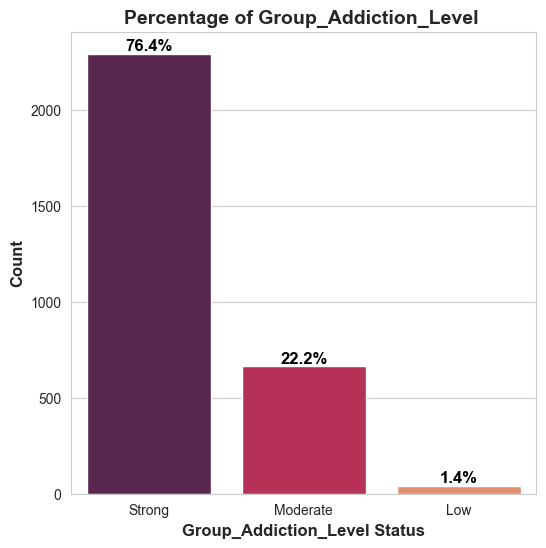

In [143]:
sns.set_style("whitegrid")
churn_counts = df["Group_Addiction_Level"].value_counts(normalize=True)*100

plt.figure(figsize=(6, 6))
ax = sns.barplot(x=churn_counts.index, y=df["Group_Addiction_Level"].value_counts(), palette="rocket")

plt.title("Percentage of Group_Addiction_Level ", fontsize=14, fontweight='bold')
plt.xlabel("Group_Addiction_Level Status", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')

for p, percentage in zip(ax.patches, churn_counts.values):
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black')
plt.show()

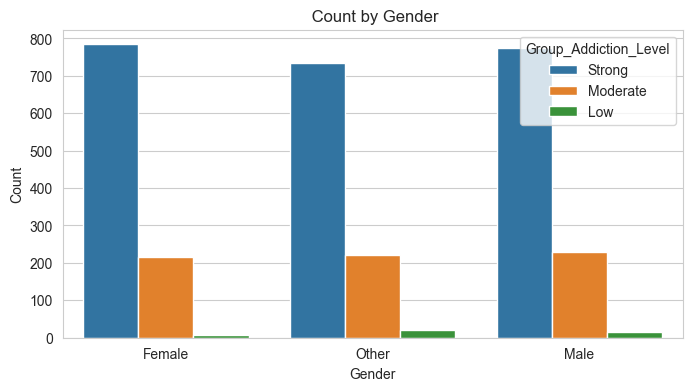

In [144]:
plt.figure(figsize=(8,4))
sns.countplot(x='Gender', hue='Group_Addiction_Level', data=df)
plt.title(' Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

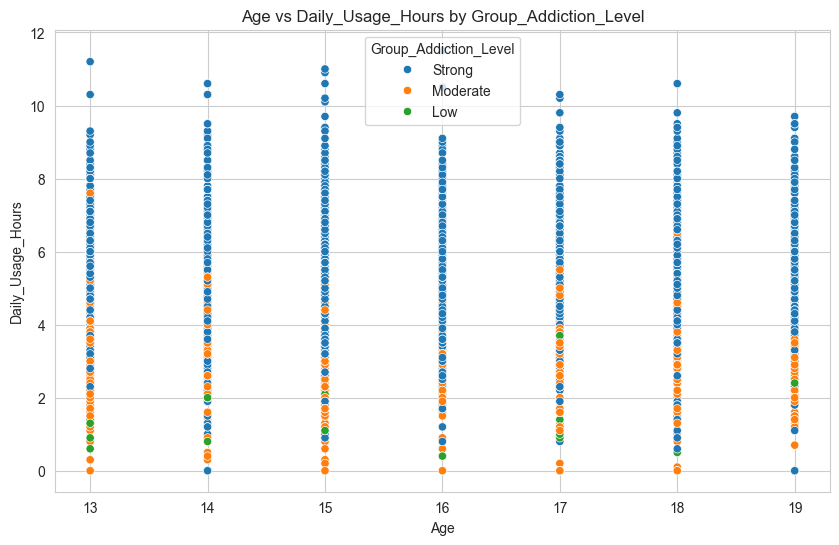

In [145]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Age', y='Daily_Usage_Hours', hue='Group_Addiction_Level', data=df)
plt.title('Age vs Daily_Usage_Hours by Group_Addiction_Level')
plt.xlabel('Age')
plt.ylabel('Daily_Usage_Hours')
plt.show()

<Axes: xlabel='Gender', ylabel='Age'>

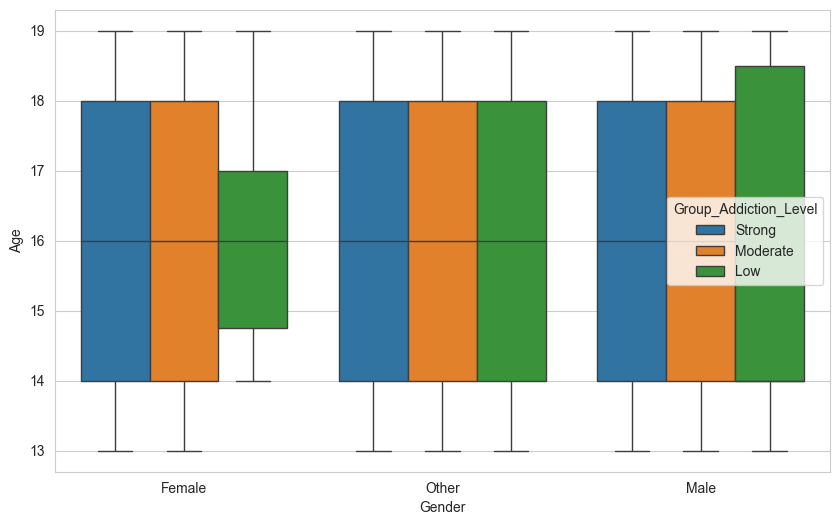

In [146]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Gender', y="Age", hue='Group_Addiction_Level', data=df)

<h1 style="color:#1E90FF; text-align:center;">📊 Insights – Grouped Addiction Level Distribution</h1>

<h2 style="color:#FF4500;">1️⃣ Addiction Level Distribution</h2>
<ul>
  <li><b>High (Strong):</b> <span style="color:#FF4500;">76% of the data – the majority of teens fall here.</span></li>
  <li><b>Medium (Moderate):</b> <span style="color:#DAA520;">22% of the data – significantly fewer teens compared to High.</span></li>
  <li><b>Low:</b> <span style="color:#2E8B57;">1.4% of the data – extremely underrepresented.</span></li>
</ul>

<h2 style="color:#FF4500;">2️⃣ Observations</h2>
<ul>
  <li><span style="color:#B22222;">Severe class imbalance exists – models trained on this data may be biased towards predicting High addiction.</span></li>
  <li><span style="color:#4682B4;">Low addiction group is critically underrepresented (only 1.4%), making accurate prediction difficult.</span></li>
  <li><span style="color:#FF1493;">Moderate group is somewhat better represented, but still much smaller than High.</span></li>
</ul>

<h2 style="color:#FF4500;">3️⃣ Implications</h2>
<ul>
  <li><span style="color:#2E8B57;">Machine learning models need handling for imbalance (e.g., oversampling Low/Moderate, SMOTE, class weighting).</span></li>
  <li><span style="color:#DAA520;">Evaluation metrics should consider per-class performance (e.g., F1-score, recall per class) rather than overall accuracy.</span></li>
  <li><span style="color:#FF4500;">Insights from features should focus on differentiating Low and Moderate cases, which are rare but important.</span></li>
</ul>

<h2 style="color:#FF4500;">4️⃣ Recommendations</h2>
<ul>
  <li><span style="color:#2E8B57;">Apply resampling or synthetic data generation to balance the target classes before training.</span></li>
  <li><span style="color:#DAA520;">Use stratified train/test splits to maintain class proportions.</span></li>
  <li><span style="color:#FF1493;">Focus on features that help identify Low and Moderate addiction teens effectively.</span></li>
</ul>

<h1 style="color:#1E90FF; text-align:center;">Nulls & OutLiares & Duplicates</h1>

<h2 style="color:#FF4500;">📊 Data Distribution Insight</h2>
<ul>
  <li><span style="color:#B22222;">The numerical features in the dataset are not normally distributed (skewed) – reflecting real-life smartphone usage patterns.</span></li>
  <li><span style="color:#4682B4;">All values are kept in their original scale – no transformations applied.</span></li>
  <li><span style="color:#2E8B57;">No duplicate rows exist – each record represents a unique teen.</span></li>
  <li><span style="color:#DAA520;">Outliers are preserved intentionally – extreme values reflect real usage and are important for analysis.</span></li>
</ul>

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 26px;
">
    Feature Enginering
</div>

In [147]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,Age,int64,"[16, 13, 15, 14, 19, 17, 18]",7,0,0.0,0
1,Gender,object,"[Male, Female, Other]",3,0,0.0,0
2,Daily_Usage_Hours,float64,"[4.4, 4.9, 4.3, 5.3, 5.0, 5.4, 4.7, 6.2, 4.1, ...",107,0,0.0,0
3,Sleep_Hours,float64,"[6.1, 7.1, 6.5, 6.8, 6.9, 5.8, 6.6, 6.3, 6.2, ...",71,0,0.0,0
4,Academic_Performance,int64,"[93, 98, 59, 62, 82, 57, 84, 77, 75, 85]",51,0,0.0,0
5,Social_Interactions,int64,"[8, 5, 9, 6, 4, 3, 1, 10, 7, 0]",11,0,0.0,0
6,Exercise_Hours,float64,"[0.0, 0.9, 1.1, 1.0, 0.8, 1.3, 1.4, 1.2, 1.5, ...",39,0,0.0,0
7,Anxiety_Level,int64,"[10, 9, 6, 5, 4, 2, 7, 1, 8, 3]",10,0,0.0,0
8,Depression_Level,int64,"[1, 6, 4, 5, 9, 7, 3, 10, 8, 2]",10,0,0.0,0
9,Self_Esteem,int64,"[7, 6, 9, 1, 3, 8, 10, 4, 5, 2]",10,0,0.0,0


In [148]:
#  Non_Educational_Time
df['Non_Educational_Time'] = df['Time_on_Social_Media'] + df['Time_on_Gaming']

In [149]:
# Social_Media_Ratio
df['Total_Time'] = df['Time_on_Social_Media'] + df['Time_on_Gaming'] + df['Time_on_Education']
df['Social_Media_Ratio'] = df['Time_on_Social_Media'] / df['Total_Time']

In [150]:
# #  Study_to_Social_Ratio
# df['Study_to_Social_Ratio'] = df['Time_on_Education'] / df['Time_on_Social_Media']

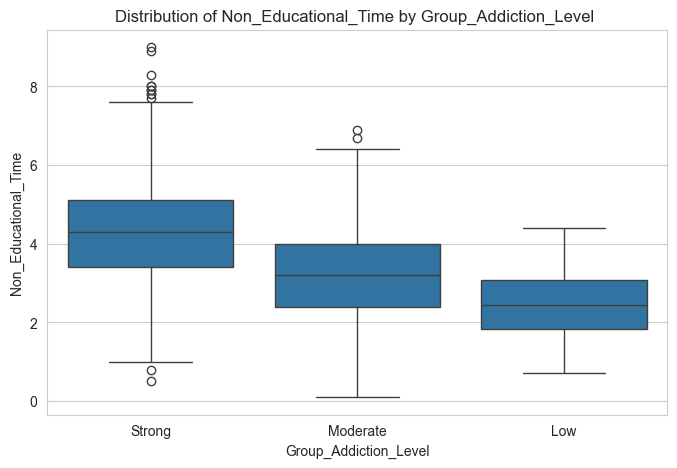

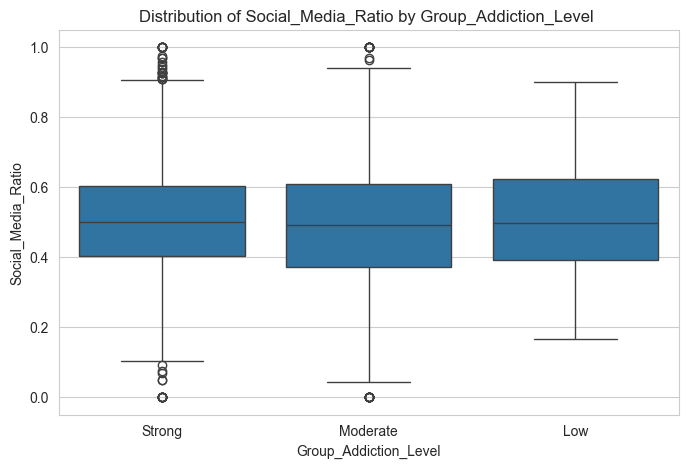

In [151]:
features = ['Non_Educational_Time', 'Social_Media_Ratio', ]

for feature in features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Group_Addiction_Level', y=feature, data=df)
    plt.title(f'Distribution of {feature} by Group_Addiction_Level ')
    plt.show()

In [152]:
print(df.columns.tolist())

['Age', 'Gender', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours', 'Group_Addiction_Level', 'Non_Educational_Time', 'Total_Time', 'Social_Media_Ratio']


<h1 style="color:#1E90FF; text-align:center;">📊 Insights – New Derived Features</h1>

<h2 style="color:#FF4500;">1️⃣ Non_Educational_Time</h2>
<ul>
  <li><span style="color:#B22222;">High Non_Educational_Time is strongly associated with High Addiction_Level (majority of teens in High category spend more time on Social Media + Games).</span></li>
  <li><span style="color:#4682B4;">Low Non_Educational_Time correlates with Low Addiction_Level.</span></li>
</ul>

<h2 style="color:#FF4500;">2️⃣ Social_Media_Ratio</h2>
<ul>
  <li><span style="color:#DAA520;">Higher ratio indicates a teen spends more of their total digital time on social media, often leading to higher Addiction_Level.</span></li>
  <li><span style="color:#2E8B57;">Lower ratio suggests a more balanced or gaming-heavy usage pattern, associated with Medium or Low Addiction_Level.</span></li>
</ul>

<h2 style="color:#FF4500;">3️⃣ Study_to_Social_Ratio</h2>
<ul>
  <li><span style="color:#FF1493;">Low Study_to_Social_Ratio indicates less study time relative to social media usage → correlated with High Addiction_Level.</span></li>
  <li><span style="color:#4682B4;">Higher ratio suggests focus on education → correlated with Low Addiction_Level.</span></li>
</ul>

<h2 style="color:#FF4500;">Summary Insight</h2>
<ul>
  <li><span style="color:#2E8B57;">These 3 derived features capture key behavior patterns and are highly indicative of addiction levels.</span></li>
  <li><span style="color:#DAA520;">Non_Educational_Time shows overall time spent on leisure vs study.</span></li>
  <li><span style="color:#B22222;">Social_Media_Ratio highlights social media dominance in total usage.</span></li>
  <li><span style="color:#FF1493;">Study_to_Social_Ratio shows balance between study and social media time – useful to distinguish Low vs Medium/High addiction.</span></li>
</ul>

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 26px;
">
    Spilting
</div>

In [153]:
x=df.drop('Group_Addiction_Level',axis=1)
y=df['Group_Addiction_Level']

In [154]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 26px;
">
    Encoding 
</div>

In [155]:
from category_encoders import OneHotEncoder



encoder_Gender = OneHotEncoder(cols=['Gender'], use_cat_names=True)
encoder_Purpose = OneHotEncoder(cols=['Phone_Usage_Purpose'], use_cat_names=True)

x_train = encoder_Gender.fit_transform(x_train)
x_test = encoder_Gender.transform(x_test)
x_train = encoder_Purpose.fit_transform(x_train)
x_test = encoder_Purpose.transform(x_test)

    

In [157]:
data_info(x_train)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,Age,int64,"[16, 13, 15, 19, 14, 17, 18]",7,0,0.0,0
1,Gender_Female,int64,"[0, 1]",2,0,0.0,0
2,Gender_Male,int64,"[0, 1]",2,0,0.0,0
3,Gender_Other,int64,"[0, 1]",2,0,0.0,0
4,Daily_Usage_Hours,float64,"[4.4, 4.9, 4.3, 5.4, 5.3, 5.2, 4.7, 4.8, 6.2, ...",103,0,0.0,0
5,Sleep_Hours,float64,"[7.1, 6.8, 6.5, 6.1, 6.3, 6.9, 6.7, 6.6, 5.9, ...",71,0,0.0,0
6,Academic_Performance,int64,"[98, 93, 62, 59, 57, 90, 75, 61, 51, 50]",51,0,0.0,0
7,Social_Interactions,int64,"[8, 5, 6, 9, 10, 1, 4, 3, 7, 0]",11,0,0.0,0
8,Exercise_Hours,float64,"[0.0, 0.9, 1.0, 1.1, 1.3, 0.8, 0.6, 0.4, 1.4, ...",38,0,0.0,0
9,Anxiety_Level,int64,"[9, 10, 4, 8, 5, 6, 7, 2, 1, 3]",10,0,0.0,0


<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 26px;
">
    Balance
</div>

In [158]:
print(pd.Series(y_train).value_counts())

Group_Addiction_Level
Strong      1837
Moderate     531
Low           32
Name: count, dtype: int64


In [159]:
smote=SMOTE(random_state=42)

x_train, y_train = smote.fit_resample(x_train, y_train)

print(pd.Series(y_train).value_counts())

Group_Addiction_Level
Strong      1837
Moderate    1837
Low         1837
Name: count, dtype: int64


<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 26px;
">
    Colleration
</div>

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 18px;
">
    (Chi-Square)
</div>

In [160]:
from scipy.stats import pointbiserialr

binary_cols = [
    'Gender_Female',
    'Gender_Male',
    'Gender_Other',
    'Phone_Usage_Purpose_Gaming',
    'Phone_Usage_Purpose_Other',
    'Phone_Usage_Purpose_Browsing',
    'Phone_Usage_Purpose_Social Media',
    'Phone_Usage_Purpose_Education'
]


chi_results = {}
for col in binary_cols:
    contingency = pd.crosstab (x_train[col], y_train)
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_results[col] = {'Chi2': chi2, 'p-value': p}

chi_results_df = pd.DataFrame(chi_results).T.sort_values(by='Chi2', ascending=False)
print(chi_results_df)


                                        Chi2        p-value
Gender_Female                     662.745068  1.221060e-144
Phone_Usage_Purpose_Browsing      419.652362   7.475624e-92
Phone_Usage_Purpose_Gaming        373.371616   8.382695e-82
Gender_Male                       323.721615   5.066924e-71
Phone_Usage_Purpose_Other         220.521952   1.300968e-48
Phone_Usage_Purpose_Social Media  198.254996   8.901733e-44
Phone_Usage_Purpose_Education     189.519051   7.022001e-42
Gender_Other                       97.148544   8.025308e-22


<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 18px;
">
    (ANOVA)
</div>

In [161]:


numeric_cols = [
    'Age',
    'Daily_Usage_Hours',
    'Sleep_Hours',
    'Academic_Performance',
    'Social_Interactions',
    'Exercise_Hours',
    'Anxiety_Level',
    'Depression_Level',
    'Self_Esteem',
    'Parental_Control',
    'Screen_Time_Before_Bed',
    'Phone_Checks_Per_Day',
    'Apps_Used_Daily',
    'Time_on_Social_Media',
    'Time_on_Gaming',
    'Time_on_Education',
    'Family_Communication',
    'Weekend_Usage_Hours',
    'Non_Educational_Time',
    'Total_Time',
    'Social_Media_Ratio'
]


# Define numircal_cols by selecting numerical columns from x_train
# numircal_cols = x_train.select_dtypes(include=np.number).columns
f_scores, p_values = f_classif(x_train[numeric_cols], y_train)
for col, f_score, p_value in zip(numeric_cols, f_scores, p_values):
    print(f"Feature: {col}, F-Score: {f_score:.4f}, P-Value: {p_value:.4f}")

Feature: Age, F-Score: 122.5677, P-Value: 0.0000
Feature: Daily_Usage_Hours, F-Score: 4001.9727, P-Value: 0.0000
Feature: Sleep_Hours, F-Score: 270.4662, P-Value: 0.0000
Feature: Academic_Performance, F-Score: 4.3957, P-Value: 0.0124
Feature: Social_Interactions, F-Score: 119.0220, P-Value: 0.0000
Feature: Exercise_Hours, F-Score: 73.1588, P-Value: 0.0000
Feature: Anxiety_Level, F-Score: 53.8915, P-Value: 0.0000
Feature: Depression_Level, F-Score: 18.6989, P-Value: 0.0000
Feature: Self_Esteem, F-Score: 10.1421, P-Value: 0.0000
Feature: Parental_Control, F-Score: 85.6480, P-Value: 0.0000
Feature: Screen_Time_Before_Bed, F-Score: 0.0119, P-Value: 0.9882
Feature: Phone_Checks_Per_Day, F-Score: 723.5824, P-Value: 0.0000
Feature: Apps_Used_Daily, F-Score: 982.5735, P-Value: 0.0000
Feature: Time_on_Social_Media, F-Score: 587.1216, P-Value: 0.0000
Feature: Time_on_Gaming, F-Score: 425.8865, P-Value: 0.0000
Feature: Time_on_Education, F-Score: 2.5699, P-Value: 0.0766
Feature: Family_Communicat

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 26px;
">
     Model Training
</div>

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 18px;
">
     Logistic
</div>

In [162]:
# log_reg = LogisticRegression(max_iter=1000, random_state=42)

# param_grid = {
#     'penalty': ['l1', 'l2'],
#     'C': [0.01, 0.1, 1, 10, 100],
#     'class_weight': [None, 'balanced']
# }

# grid_search = GridSearchCV(
#     estimator=log_reg,
#     param_grid=param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=1
# )

# grid_search.fit(x_train, y_train)
# best_log_reg = grid_search.best_estimator_

# y_pred = best_log_reg.predict(x_test)
# y_pred_train = best_log_reg.predict(x_train)

# print("Best Parameters:", grid_search.best_params_)
# print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
# print("Test Accuracy:", accuracy_score(y_test, y_pred))

In [163]:
# log_reg_final=LogisticRegression(C=10, class_weight=None, penalty='l2', max_iter=1000, random_state=42)
# log_reg_final.fit(x_train, y_train)

# y_pred_final = log_reg_final.predict(x_test)
# y_pred_train_final = log_reg_final.predict(x_train)

# print("Train Accuracy:", accuracy_score(y_train, y_pred_train_final))
# print("Test Accuracy:", accuracy_score(y_test, y_pred_final))

# print(classification_report(y_test, y_pred_final, target_names=['Low', 'Moderate','Strong']))

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 18px;
">
    SVM With Grid Search
</div>

In [164]:
# svm_model = SVC(probability=True, random_state=42)

# param_grid = {
#     'C': [0.1, 1, 10, 100],
#     'kernel': ['linear', 'rbf', 'poly'],
#     'gamma': ['scale', 'auto'],
#     'class_weight': [None, 'balanced']
# }

# grid_search = GridSearchCV(
#     estimator=svm_model,
#     param_grid=param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1,
# )

# grid_search.fit(x_train, y_train)
# best_svm = grid_search.best_estimator_

# y_pred = best_svm.predict(x_test)
# y_pred_train = best_svm.predict(x_train)

# print("Best Parameters:", grid_search.best_params_)
# print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
# print("Test Accuracy:", accuracy_score(y_test, y_pred))

<!-- Simple Markdown HTML -->
<div style="
    background-color: #1e1e2f;
    color: #ff6f61;
    padding: 15px 25px;
    border-radius: 12px;
    font-family: monospace;
    font-size: 18px;
">
    SVM Best Parameters
</div>

In [165]:
svm_final = SVC(C=100, kernel='linear', gamma='scale', class_weight='balanced', probability=True, random_state=42)
svm_final.fit(x_train, y_train)

y_pred_final = svm_final.predict(x_test)
y_pred_train_final = svm_final.predict(x_train)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_final))
print("Accuracy:", accuracy_score(y_test, y_pred_final))

print(classification_report(y_test, y_pred_final, target_names=['Low', 'Moderate','Strong']))

Train Accuracy: 1.0
Accuracy: 0.9916666666666667
              precision    recall  f1-score   support

         Low       1.00      0.70      0.82        10
    Moderate       0.98      0.99      0.98       134
      Strong       1.00      1.00      1.00       456

    accuracy                           0.99       600
   macro avg       0.99      0.90      0.93       600
weighted avg       0.99      0.99      0.99       600



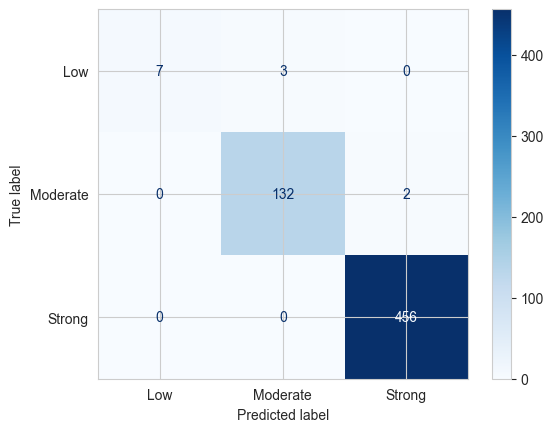

In [166]:
ConfusionMatrixDisplay.from_estimator(
    svm_final,
    x_test,
    y_test,
    cmap=plt.cm.Blues
)
plt.show()

In [167]:

import pickle
import joblib



joblib.dump(encoder_Purpose,'purpose_encoder.pkl')
joblib.dump(encoder_Gender,'gender_encoder.pkl')
joblib.dump(svm_final,'svm_final.pkl')
# joblib.dump(school_mapping,'school_mapping.pkl')
joblib.dump(x_train.columns.tolist(), "columns.pkl")




['columns.pkl']

In [168]:
import os
print(os.getcwd())

g:\Smart_Phone_Addiction_Leval


***

<BR>
    
    
<div style="text-align: center;">
   <span style="font-size: 4.5em; font-weight: bold; font-family: Arial;">THANK YOU!</span>
</div>

<div style="text-align: center;">
    <span style="font-size: 5em;">✔️</span>
</div>

<br>

 

 